In [156]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [189]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.signal import welch
from src.environment.atmosphere import Atmosphere
from src.models.dual_rotor_beam_drone import DualRotorBeamDrone
from src.models.base import State
from src.environment.dryden_wind import DrydenConfig, DrydenWindGenerator
from src.controllers.pid import PIDController

In [158]:
# Drone Model Parameters
mass = 0.5 # kg
length = 0.3 # m
width = 0.003 # m
motor_base_thrust = 5.0 # N


In [ ]:
air_density = Atmosphere().density
beam_drone = DualRotorBeamDrone(
    mass=mass,
    length=length,
    width=width,
    motor_base_thrust=motor_base_thrust,
    air_density=air_density
)



In [175]:
dryden_wind_config = DrydenConfig(
    mean_velocity=2.5,
    sigma_w=0.6,
    length_scale_Lw=30.0,
    nominal_airspeed_V=5.0
)

In [178]:
time_min = 20.0 
dt = 0.01
total_steps = int(time_min * 60.0 / dt)


wind_generator = DrydenWindGenerator(dryden_wind_config, dt=dt)
wind_velocities = wind_generator.generate_wind(num_steps=total_steps, channels=2, seed=42)
v_wind_left, v_wind_right = wind_velocities[:, 0], wind_velocities[:, 1]

# PD Controller Parameters for this drone model from Ziegler-Nichols analysis
kp = 0.4
kd = 0.6
pid_controller = PIDController(kp=kp, kd=kd, dt=dt)
pid_controller.reset()
beam_drone.reset(State)

angle_history = []
time_history = []

for step in range(total_steps):
    current_time = step * dt

    pid_output = pid_controller.compute(setpoint=0.0, measured_value=beam_drone.state.angle)

    beam_drone.step(
        pid_output=pid_output,
        v_wind_left=v_wind_left[step],
        v_wind_right=v_wind_right[step],
    )


    time_history.append(current_time)
    angle_history.append(beam_drone.state.angle)


In [180]:
angle_history_deg = np.degrees(angle_history)

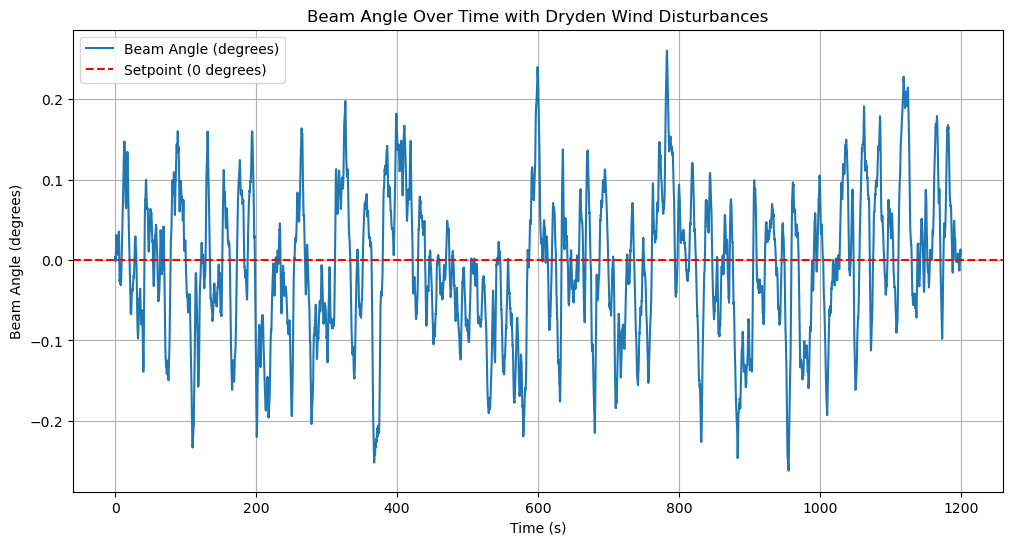

In [181]:
plt.figure(figsize=(12, 6))
plt.plot(time_history, angle_history_deg, label='Beam Angle (degrees)')
plt.axhline(0, color='r', linestyle='--', label='Setpoint (0 degrees)')
plt.title('Beam Angle Over Time with Dryden Wind Disturbances')
plt.xlabel('Time (s)')
plt.ylabel('Beam Angle (degrees)')
plt.grid()
plt.legend()
plt.show()

In [187]:
# Root Mean Square Error (RMSE) Calculation
rmse_deg = np.sqrt(np.mean(np.square(angle_history_deg)))
max_deflection_deg = np.max(np.abs(angle_history_deg))
std_deg = np.std(angle_history_deg)

print("=" * 40)
print(f"10-Min Dryden Wind Test Benchmark")
print("=" * 40)
print(f"RMSE             : {rmse_deg:.4f}")
print(f"Max Deflection   : {max_deflection_deg:.4f}")
print(f"Std Deviation    : {std_deg:.4f}")

10-Min Dryden Wind Test Benchmark
RMSE             : 0.0908
Max Deflection   : 0.2620
Std Deviation    : 0.0904


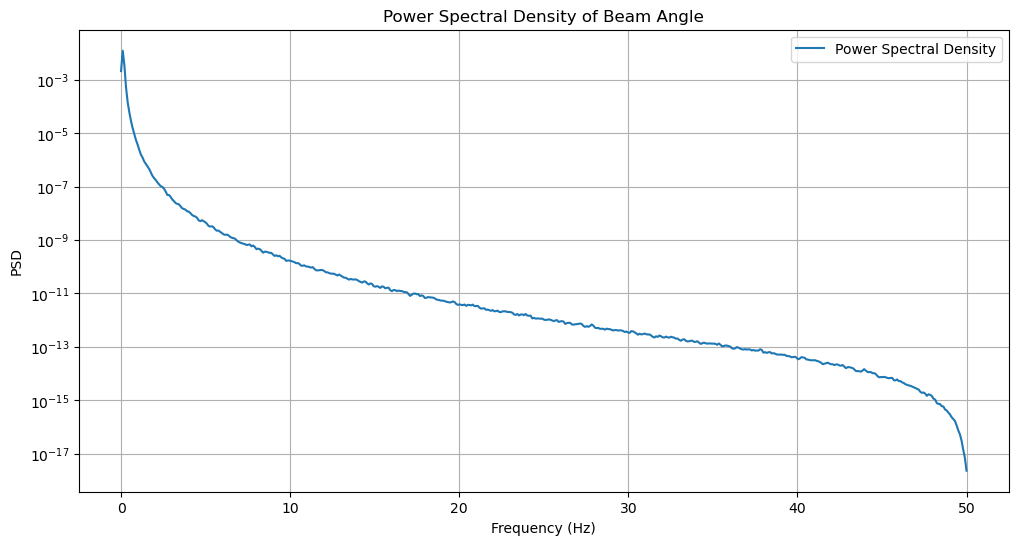

In [190]:
# Power Spectral Density Plot
freq, psd = welch(angle_history_deg, fs=1/dt, nperseg=1024)

plt.figure(figsize=(12, 6))
plt.semilogy(freq, psd, label='Power Spectral Density')
plt.title('Power Spectral Density of Beam Angle')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.grid()
plt.legend()
plt.show()